In [1]:
%load_ext autoreload
%autoreload 2

# SRE-DQN vs Nash-DQN Comparison

Trains both Nash-DQN and SRE-DQN on the same multi-agent statistical arbitrage environment
under identical conditions and compares them via:
- Training loss curves
- Policy heatmaps (optimal action over Time × Inventory)
- Reward distributions from simulation rollouts
- Head-to-head performance (Nash vs Nash, SRE vs SRE, Nash vs SRE mixed)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import pickle
from scipy import stats

from NashRL import run_Nash_Agent
from NashAgent_lib import NashNN
from SREAgent_lib import SreNN
from SREDQN import run_SRE_Agent
from PolicyGrad import sim_policy
from simulation_lib import MarketSimulator
from visualization import draw_heatmap, to_State_mesh

np.set_printoptions(precision=4)
print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')

Using device: cuda


## Shared Market Environment

Identical parameters to `NashDQN-Training.ipynb`. Both agents are trained on this same environment.

In [3]:
num_players = 5
kappa = 0.5

sim_dict = {
    'perm_price_impact':  torch.tensor(0.05).cuda().detach(),
    'transaction_cost':   torch.tensor(0.1).cuda().detach(),
    'liquidation_cost':   torch.tensor(0.1).cuda().detach(),
    'running_penalty':    torch.tensor(0.0).cuda().detach(),
    'trans_impact_scale': torch.tensor(0.02).cuda().detach(),
    'trans_impact_decay': torch.tensor(0.5).cuda().detach(),
    'T':                  torch.tensor(5).cuda().detach(),
    'dt':                 torch.tensor(0.5).cuda().detach(),
    'N_agents':           num_players,
    'drift_function':     (lambda x, y: kappa * (10 - y)),
    'volatility':         torch.tensor(0.1).cuda().detach(),
    'init_inv_var':       torch.tensor(50).cuda().detach(),
}

inv_std = sim_dict['volatility'] * torch.sqrt(
    (1 - torch.exp(-2 * kappa * sim_dict['T'])) / (2 * kappa)
)
sim_dict['initial_price_var'] = torch.tensor(inv_std).cuda().detach()

norm_mean = torch.tensor([2.25, 10, 0, 0, 0]).cuda().detach()
norm_std  = torch.tensor([
    1.4361406616345072,
    0.74204157112471332 * 0.2763,
    2.5 * 1.8078,
    0.1 * 0.4225,
    1.0 * 1.6726,
]).cuda().detach()

sim_obj = MarketSimulator(sim_dict, impact='sqrt')
T = sim_dict['T']

print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item())

Agents: 5 | T= 5 | dt= 0.5


/tmp/ipykernel_2187/3308847593.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sim_dict['initial_price_var'] = torch.tensor(inv_std).cuda().detach()


## Hyperparameters

In [4]:
# Shared training config
NUM_SIM   = 20000
MAX_STEPS = 10
RV_MIN    = 0.5
RV_MAX    = 2.5
EARLY_STOP = True
EARLY_LIM  = 1000

# Shared network config (valid for both NashNN and SreNN)
NET_KWARGS = dict(
    non_invar_dim=5,
    output_dim=5,
    n_players=num_players,
    max_steps=MAX_STEPS,
    lr=3e-4,
    weighted_adam=True,
    terminal_cost=sim_dict['liquidation_cost'],
    num_moms=0,
    c_cons=50,
    c2_cons=False,
    c3_pos=False,
    layers=4,
)

# SRE-specific hyperparameters
SRE_EPS_0    = 0.1    # initial robustness parameter ε_0
SRE_EPS_DECAY = 10000 # episode at which ε reaches 0 (B_decay)
SRE_EPS_REG  = 0.01   # Frobenius regularisation on P_12
SRE_DELTA_MIN = 1e-6  # threshold for SRE correction denominator
SRE_GAMMA    = 1.0    # discount factor (undiscounted to match Nash-DQN)

print('NUM_SIM:', NUM_SIM, '| MAX_STEPS:', MAX_STEPS)
print('SRE eps_0:', SRE_EPS_0, '| decay horizon:', SRE_EPS_DECAY)

NUM_SIM: 20000 | MAX_STEPS: 10
SRE eps_0: 0.1 | decay horizon: 10000


## Train Nash-DQN

In [6]:
import os
os.makedirs('pt_files/comparison/Nash', exist_ok=True)

nash_agent = NashNN(**NET_KWARGS)

start = time.time()
nash_agent, nash_loss = run_Nash_Agent(
    sim_obj, sim_dict, MAX_STEPS,
    nash_agent=nash_agent,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    path='pt_files/comparison/Nash/',
    AN_file_name='pt_files/comparison/Nash/Action_Net',
    VN_file_name='pt_files/comparison/Nash/Value_Net',
)
nash_train_time = time.time() - start
print(f'Nash-DQN training time: {nash_train_time:.1f}s')

CUDA IS AVAILABLE!


Nash-DQN:   0%|                                                   | 1/20000 [00:01<10:31:16,  1.89s/it, loss=17829.6465]

New best loss: 17829.646484375


Nash-DQN:   0%|                                                   | 3/20000 [00:04<10:35:41,  1.91s/it, loss=16168.9297]

New best loss: 16168.9296875


...

Iteration 7000 | Total Loss 93.9422 | V_Loss 47.1416 | A_Loss 46.8006


Nash-DQN:  36%|██████████████████                                | 7200/20000 [3:12:51<6:38:45,  1.87s/it, loss=97.5257]

Iteration 7200 | Total Loss 97.5257 | V_Loss 49.0029 | A_Loss 48.5228


Nash-DQN:  36%|██████████████████                                | 7228/20000 [3:13:38<5:42:10,  1.61s/it, loss=69.2121]

EARLY STOPPING ON ITERATION 7228
Saving final weights to disk
Weights saved to disk
Nash-DQN training time: 11618.9s


## Train SRE-DQN

In [7]:
os.makedirs('pt_files/comparison/SRE', exist_ok=True)

sre_agent = SreNN(
    **NET_KWARGS,
    eps_reg=SRE_EPS_REG,
    delta_min=SRE_DELTA_MIN,
    gamma=SRE_GAMMA,
)

start = time.time()
sre_agent, sre_loss = run_SRE_Agent(
    sim_obj, sim_dict,
    max_steps=MAX_STEPS,
    sre_agent=sre_agent,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    eps_0=SRE_EPS_0,
    eps_decay_horizon=SRE_EPS_DECAY,
    eps_reg=SRE_EPS_REG,
    delta_min=SRE_DELTA_MIN,
    gamma=SRE_GAMMA,
    path='pt_files/comparison/SRE/',
    AN_file_name='pt_files/comparison/SRE/SRE_Action_Net',
    VN_file_name='pt_files/comparison/SRE/SRE_Value_Net',
)
sre_train_time = time.time() - start
print(f'SRE-DQN training time: {sre_train_time:.1f}s')

CUDA IS AVAILABLE!


SRE-DQN:   0%|                                                                                | 0/20000 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/continous_action_space/SREAgent_lib.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ids = torch.tensor(torch.arange(self.num_players)).tile(num_entries).cuda()
SRE-DQN:   0%|                                                     | 1/20000 [00:01<8:02:23,  1.45s/it, loss=39244.1445]

New best loss: 39244.1445


SRE-DQN:   0%|                                                    | 2/20000 [00:03<10:02:19,  1.81s/it, loss=25110.7891]

New best loss: 25110.7891


...

Episode 6600 | Total Loss 66.5205 | V_loss 33.4833 | A_loss 33.0371


SRE-DQN:  34%|█████████████████▎                                 | 6801/20000 [3:20:27<9:30:46,  2.59s/it, loss=79.8822]

Episode 6800 | Total Loss 79.8822 | V_loss 40.1514 | A_loss 39.7309


SRE-DQN:  35%|█████████████████▋                                 | 6934/20000 [3:25:44<6:27:41,  1.78s/it, loss=77.2374]

EARLY STOPPING at episode 6934
SRE-DQN training time: 12344.7s


## Training Loss Curves

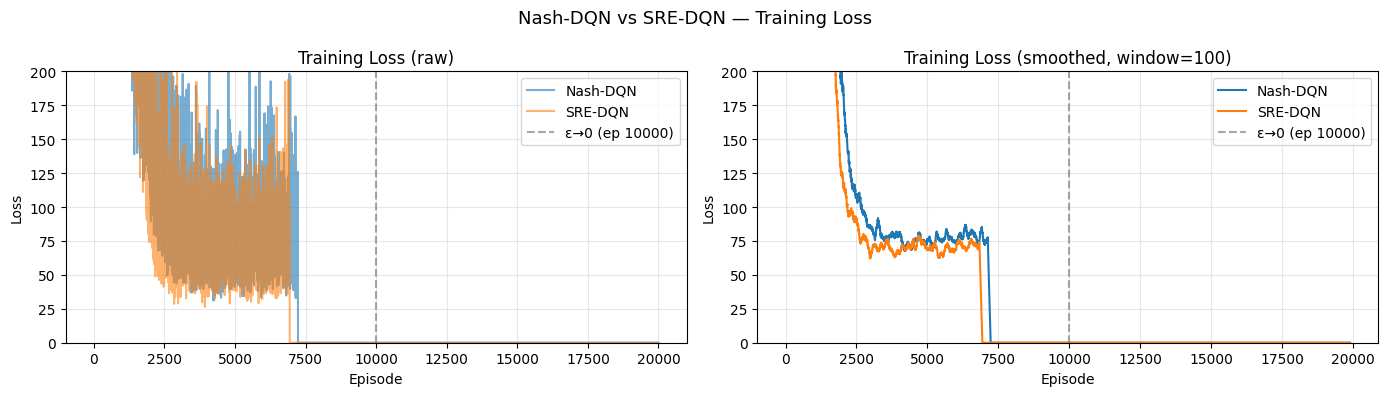

In [8]:
def smooth(arr, window=100):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw loss
ax = axes[0]
ax.plot(nash_loss, alpha=0.6, label='Nash-DQN')
ax.plot(sre_loss,  alpha=0.6, label='SRE-DQN')
ax.axvline(SRE_EPS_DECAY, color='grey', linestyle='--', alpha=0.7, label=f'ε→0 (ep {SRE_EPS_DECAY})')
ax.set_ylim(0, 200)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (raw)')
ax.legend()
ax.grid(alpha=0.3)

# Smoothed loss
ax = axes[1]
ax.plot(smooth(nash_loss), label='Nash-DQN')
ax.plot(smooth(sre_loss),  label='SRE-DQN')
ax.axvline(SRE_EPS_DECAY, color='grey', linestyle='--', alpha=0.7, label=f'ε→0 (ep {SRE_EPS_DECAY})')
ax.set_ylim(0, 200)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed, window=100)')
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle('Nash-DQN vs SRE-DQN — Training Loss', fontsize=13)
plt.tight_layout()
os.makedirs('pt_files/comparison/figures', exist_ok=True)
fig.savefig('pt_files/comparison/figures/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Policy Heatmaps — Nash-DQN

Each panel shows the optimal action (trade rate) as a function of (time remaining, inventory) at a fixed price level.

=== Nash-DQN Policy Heatmaps ===
[ 9.5   9.75 10.   10.25 10.5 ]
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


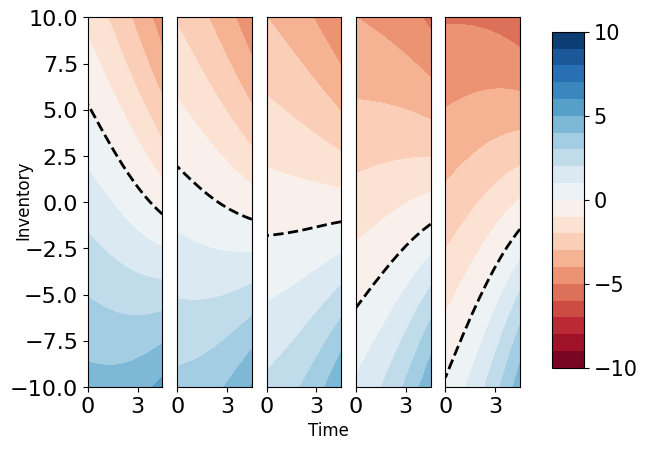

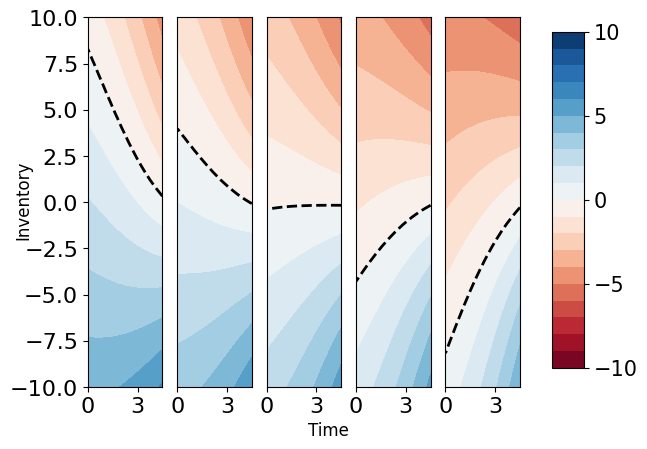

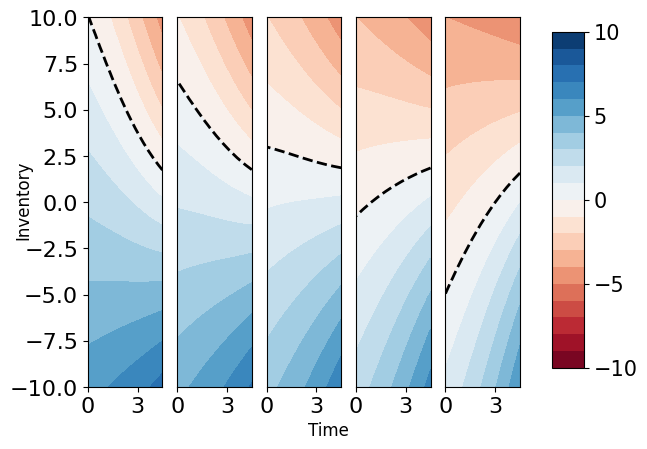

In [10]:
heatmap_kwargs = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5],
    q_range=[-10, 10],
    p_range=[9.5, 10.5],
    n_agents=num_players,
    other_agent_inv=0,
    a_range=[-10, 10],
    T=T,
    norm_mean=norm_mean,
    norm_std=norm_std,
    is_numpy=False,
    norm_input=True,
)

print('=== Nash-DQN Policy Heatmaps ===')
for i_val in [0.2, 0.0, -0.2]:
    draw_heatmap(net=nash_agent, i_val=i_val, **heatmap_kwargs)

## Policy Heatmaps — SRE-DQN

`SreNN.predict_action` returns the same 5-column format as `NashNN.predict_action`, so `draw_heatmap` works without modification. Column 4 (mu) is the learned Nash action, shaped by SRE Bellman targets during training.

=== SRE-DQN Policy Heatmaps (Nash mu, SRE-trained) ===
[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


[ 9.5   9.75 10.   10.25 10.5 ]


/home/wowthecoder/SRE-DQN/continous_action_space/visualization.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_list.append(State(t=torch.tensor(T-t).cuda().float(),


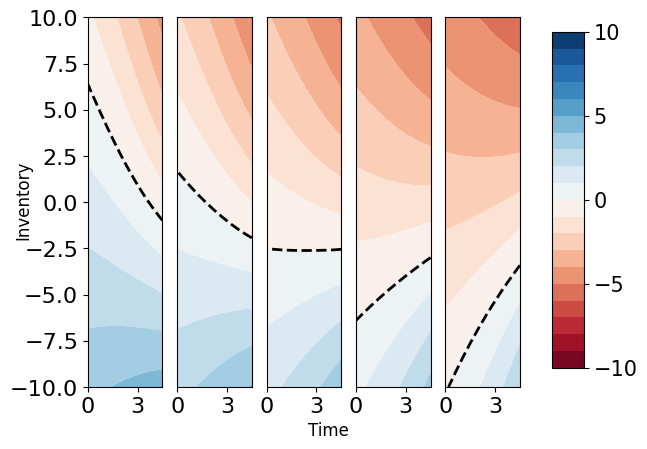

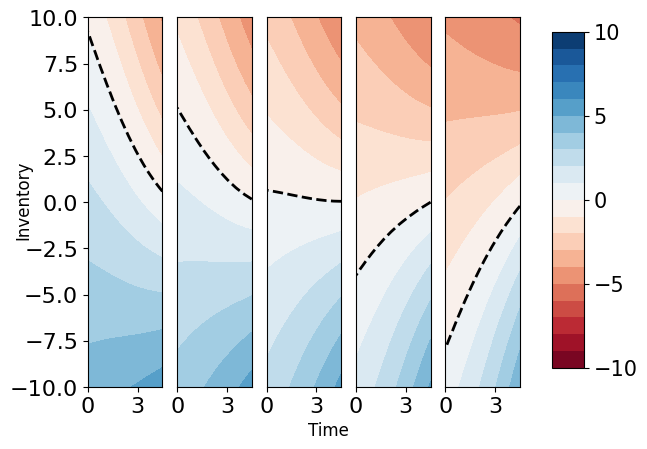

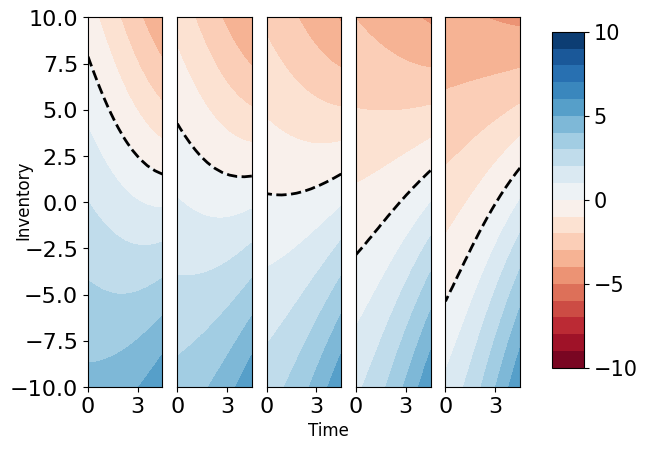

In [11]:
print('=== SRE-DQN Policy Heatmaps (Nash mu, SRE-trained) ===')
for i_val in [0.2, 0.0, -0.2]:
    draw_heatmap(net=sre_agent, i_val=i_val, **heatmap_kwargs)

## Policy Heatmaps — SRE-Corrected Action

Shows the actual SRE action `μ^SR = μ + ε·correction` at a fixed epsilon, visualising the robustness adjustment on top of the Nash mu.

=== SRE-DQN Corrected Action Heatmaps (ε=0.01) ===


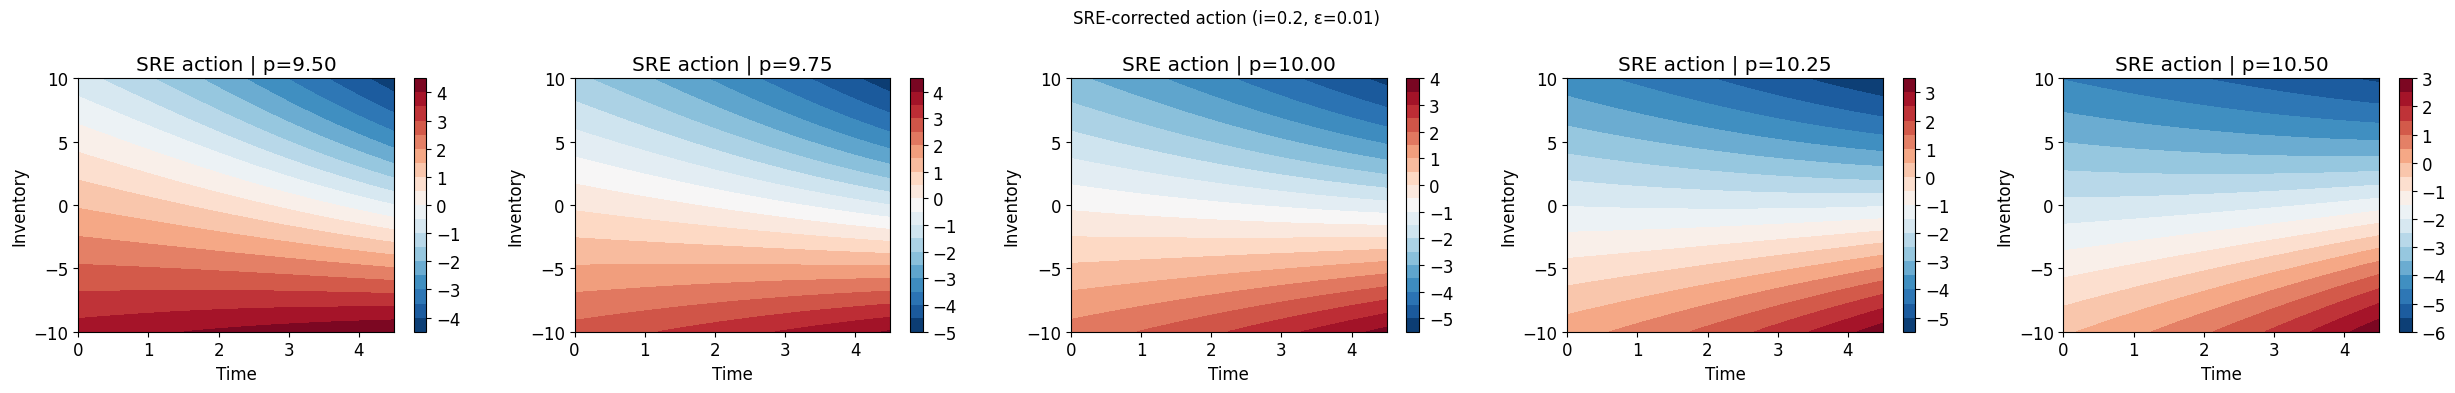

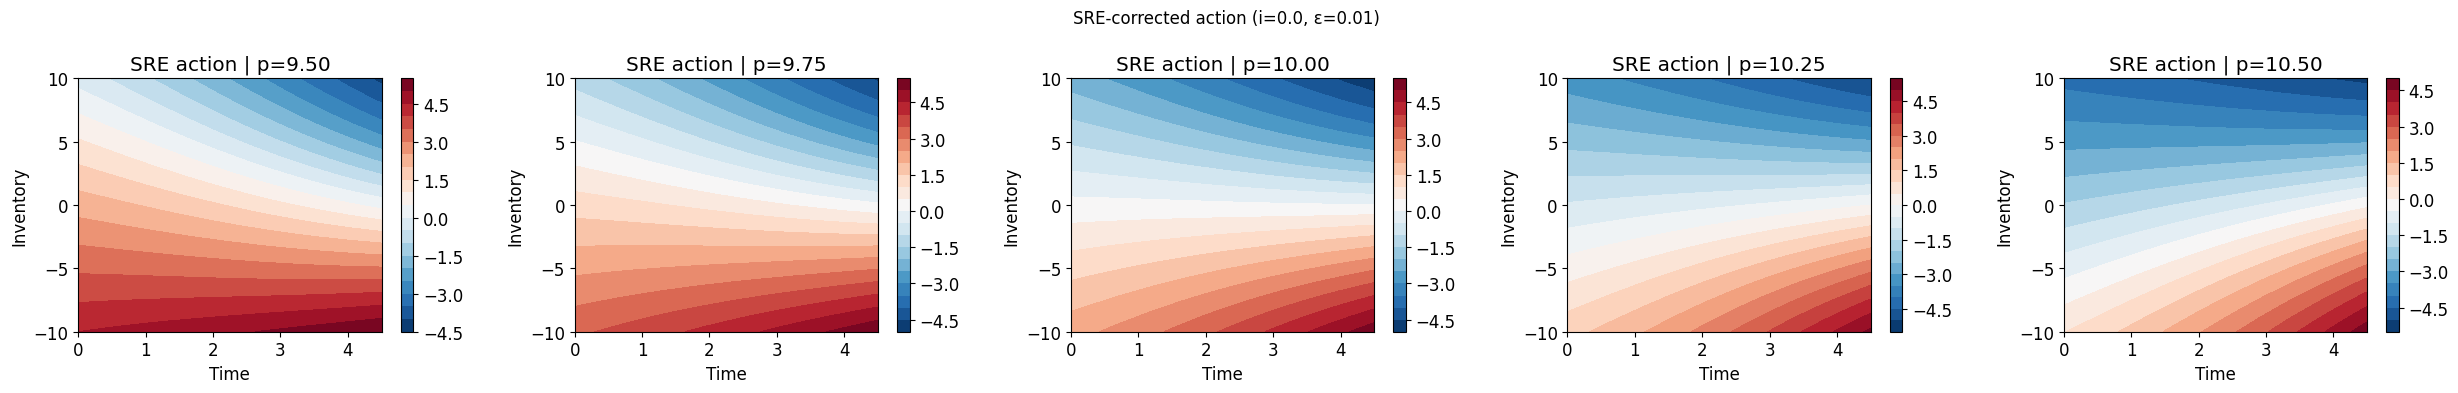

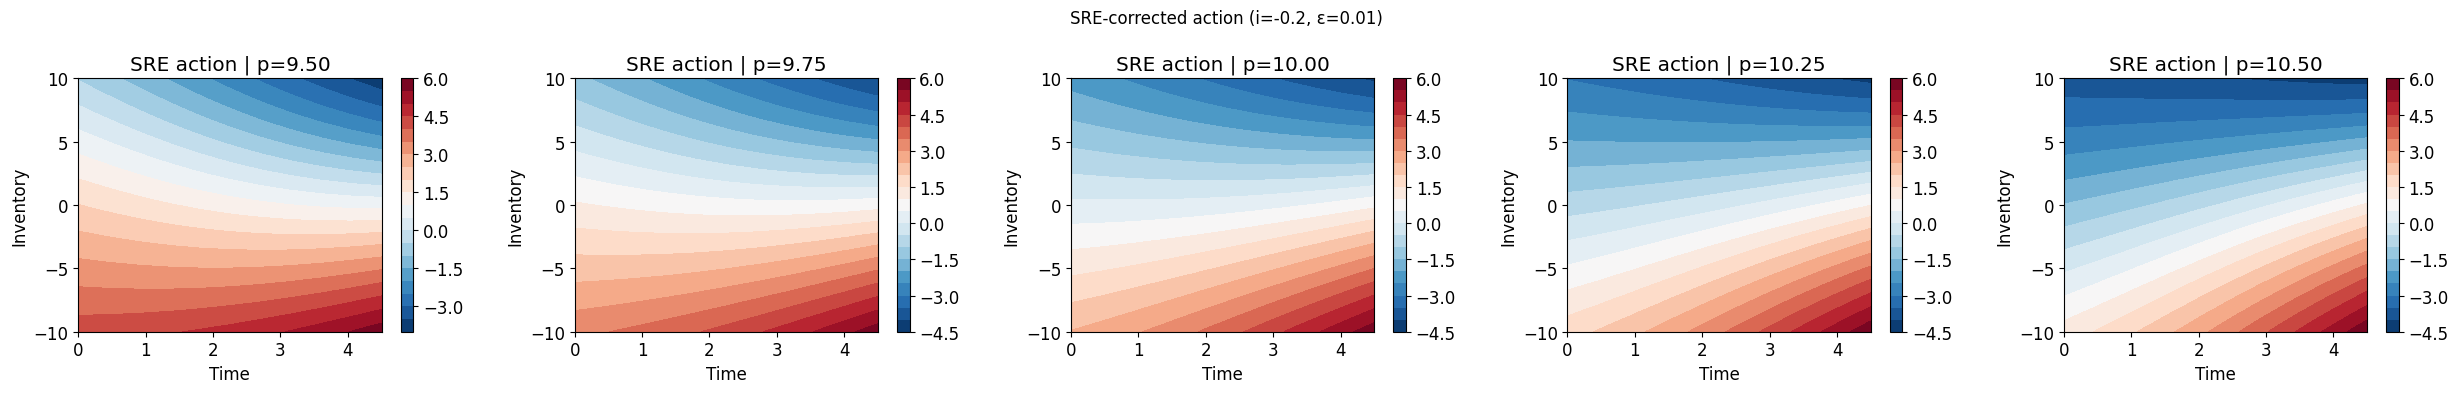

In [12]:
def to_State_mesh_sre(agent, eps, t_step, q_step, p_step,
                      t_range, q_range, p_range, n_agents,
                      other_agent_inv, norm_mean, norm_std, i_val, T):
    """Like to_State_mesh but uses compute_sre_action instead of predict_action[:,4]."""
    from simulation_lib import State
    t_arr = np.linspace(t_range[0], t_range[1], t_step)
    q_arr = np.linspace(q_range[0], q_range[1], q_step)
    p_arr = np.linspace(p_range[0], p_range[1], p_step)

    action_mesh = np.zeros((p_step, t_step, q_step))

    for pi, p in enumerate(p_arr):
        for ti, t in enumerate(t_arr):
            for qi, q in enumerate(q_arr):
                q_arr_full = np.array([q] + [other_agent_inv] * (n_agents - 1))
                state = State(
                    t=T - torch.tensor(t),
                    p=torch.tensor(p),
                    i=torch.tensor(i_val),
                    q=torch.tensor(q_arr_full, dtype=torch.float32),
                    q0=torch.zeros(n_agents),
                )
                in_ivt, ivt = state.to_sep_numpy(0, norm_mean, norm_std)
                if ivt is not None:
                    mu_sr = agent.compute_sre_action(
                        in_ivt.unsqueeze(0), ivt.unsqueeze(0), eps
                    )
                else:
                    mu_sr = agent.compute_sre_action(
                        in_ivt.unsqueeze(0), ivt, eps
                    )
                action_mesh[pi, ti, qi] = mu_sr[0].item()

    return p_arr, t_arr, q_arr, action_mesh


SRE_VIZ_EPS = 0.01
print(f'=== SRE-DQN Corrected Action Heatmaps (ε={SRE_VIZ_EPS}) ===')

mesh_kwargs = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5], q_range=[-10, 10], p_range=[9.5, 10.5],
    n_agents=num_players, other_agent_inv=0,
    norm_mean=norm_mean, norm_std=norm_std, T=T,
)

for i_val in [0.2, 0.0, -0.2]:
    p_arr, t_arr, q_arr, action_mesh = to_State_mesh_sre(
        sre_agent, SRE_VIZ_EPS, i_val=i_val, **mesh_kwargs
    )
    fig, axes = plt.subplots(1, len(p_arr), figsize=(5 * len(p_arr), 4))
    if len(p_arr) == 1:
        axes = [axes]
    for pi, (ax, p) in enumerate(zip(axes, p_arr)):
        c = ax.contourf(t_arr, q_arr, action_mesh[pi].T, levels=20, cmap='RdBu_r')
        plt.colorbar(c, ax=ax)
        ax.set_xlabel('Time')
        ax.set_ylabel('Inventory')
        ax.set_title(f'SRE action | p={p:.2f}')
    fig.suptitle(f'SRE-corrected action (i={i_val}, ε={SRE_VIZ_EPS})', fontsize=12)
    plt.tight_layout()
    plt.show()

## Policy Difference Heatmaps

Difference between SRE-DQN and Nash-DQN Nash-mu at each price level. Diverging colormap: red = SRE more aggressive, blue = Nash more aggressive.

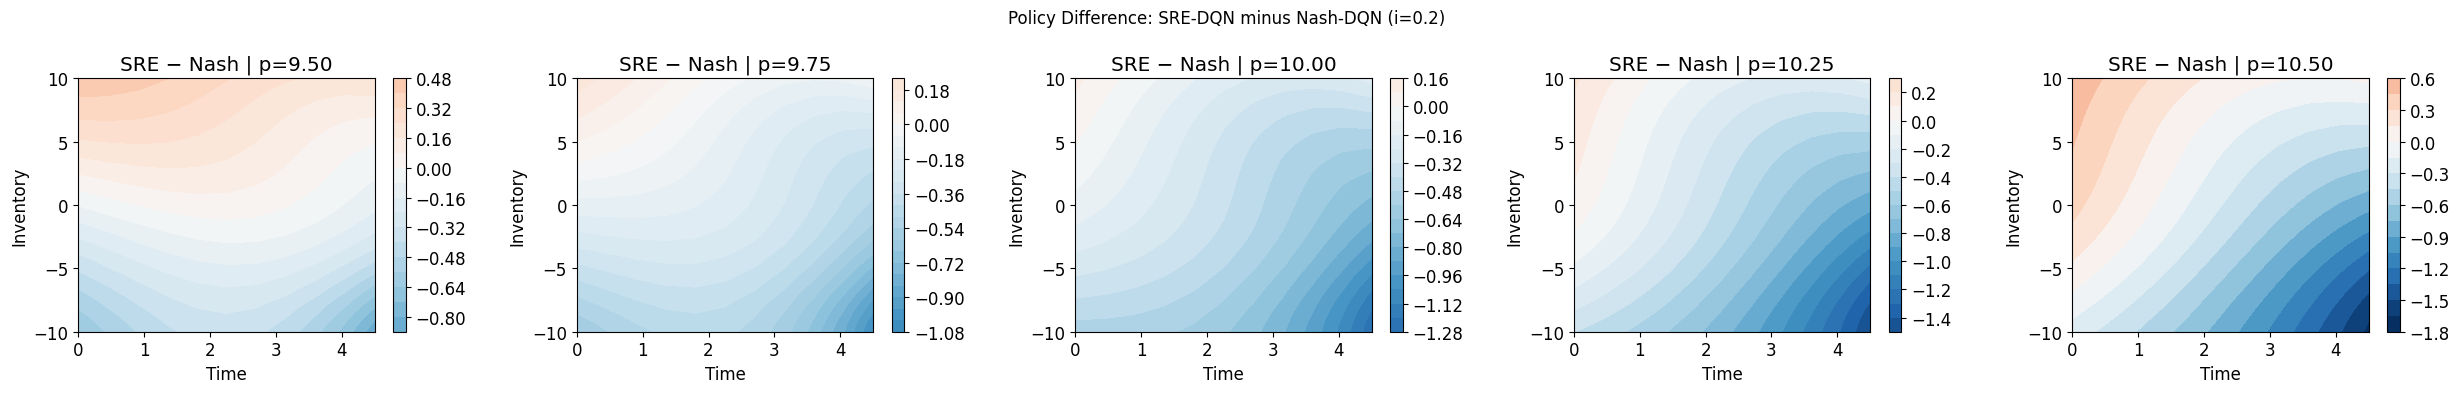

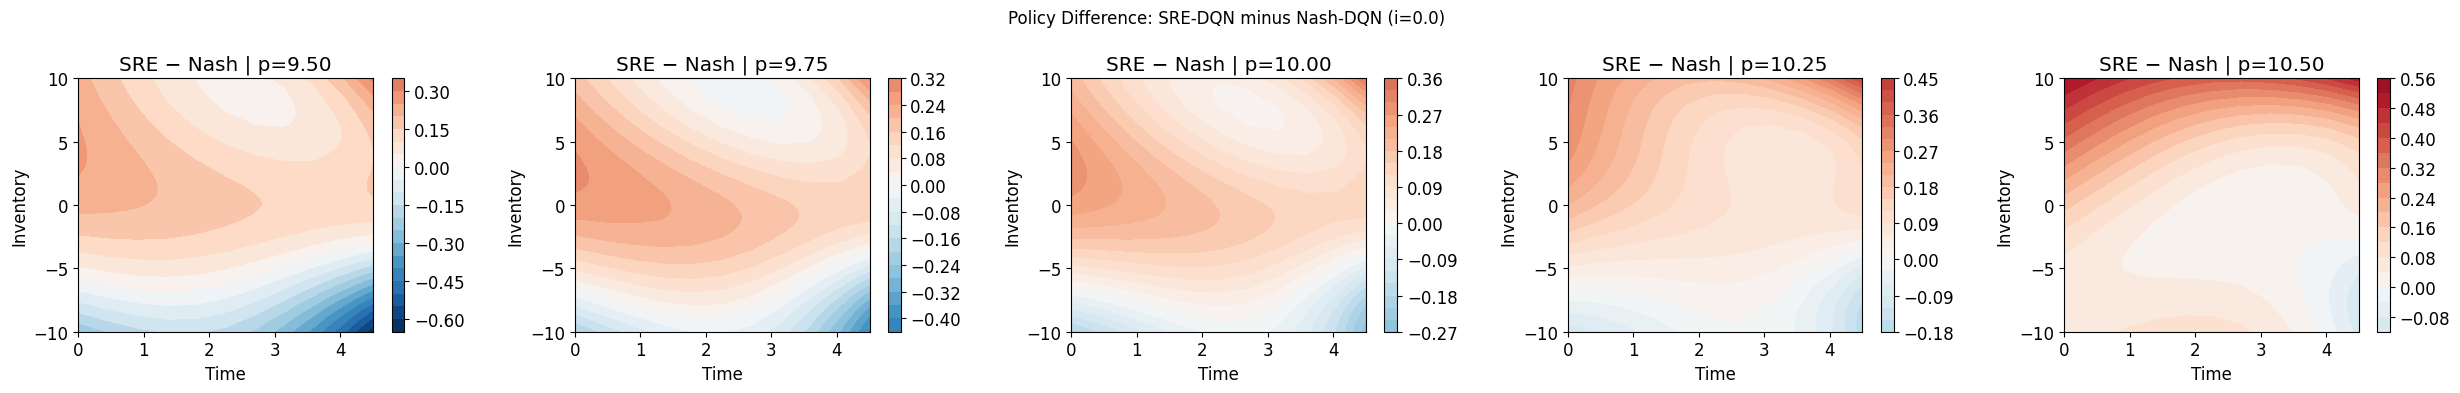

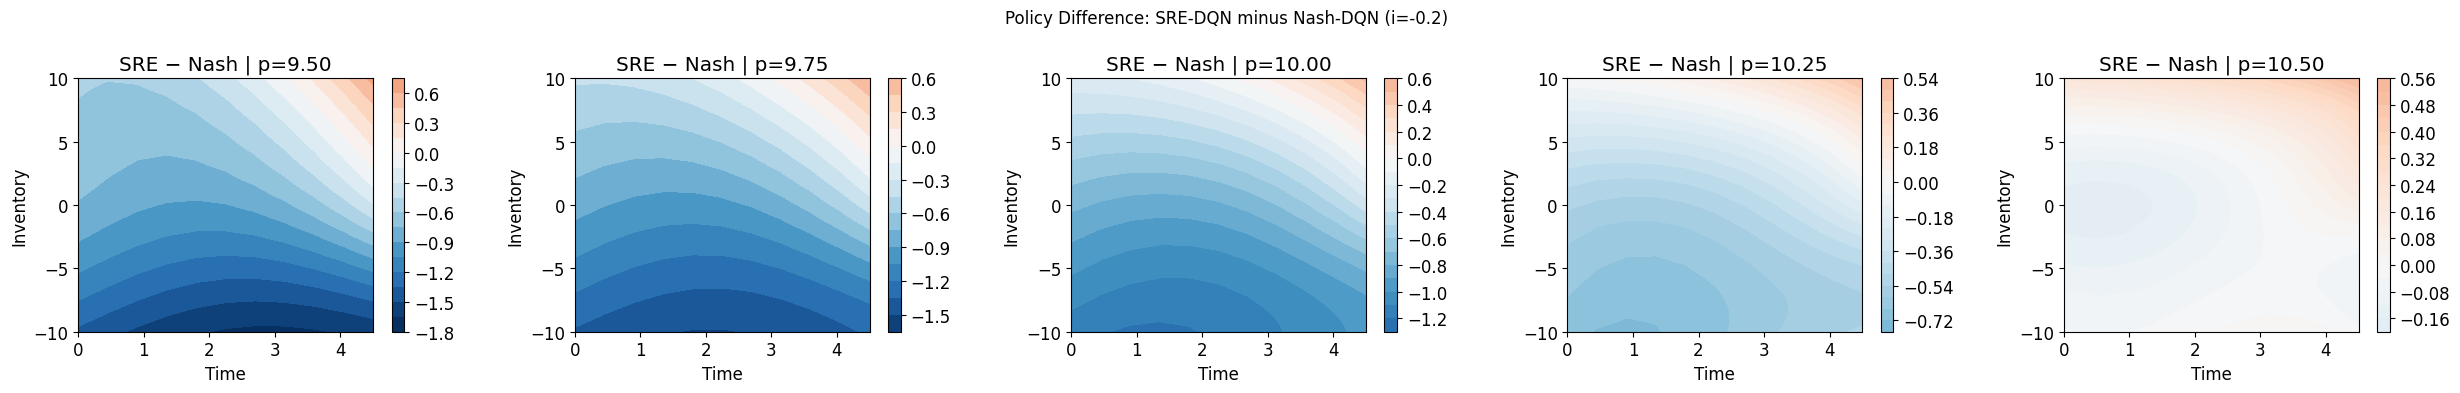

In [13]:
def get_nash_action_mesh(agent, t_step, q_step, p_step, t_range, q_range, p_range,
                         n_agents, other_agent_inv, norm_mean, norm_std, i_val, T):
    """Extract Nash-mu action mesh from predict_action[:,4]."""
    from simulation_lib import State
    t_arr = np.linspace(t_range[0], t_range[1], t_step)
    q_arr = np.linspace(q_range[0], q_range[1], q_step)
    p_arr = np.linspace(p_range[0], p_range[1], p_step)
    action_mesh = np.zeros((p_step, t_step, q_step))

    agent.action_net.eval()
    with torch.no_grad():
        for pi, p in enumerate(p_arr):
            for ti, t in enumerate(t_arr):
                for qi, q in enumerate(q_arr):
                    q_full = np.array([q] + [other_agent_inv] * (n_agents - 1))
                    state = State(
                        t=T - torch.tensor(t),
                        p=torch.tensor(p),
                        i=torch.tensor(i_val),
                        q=torch.tensor(q_full, dtype=torch.float32),
                        q0=torch.zeros(n_agents),
                    )
                    in_ivt, ivt = state.to_sep_numpy(0, norm_mean, norm_std)
                    if ivt is not None:
                        a = agent.predict_action(in_ivt.unsqueeze(0), ivt.unsqueeze(0))[0, 4]
                    else:
                        a = agent.predict_action(in_ivt.unsqueeze(0), ivt)[0, 4]
                    action_mesh[pi, ti, qi] = a.item()
    return p_arr, t_arr, q_arr, action_mesh


mesh_base = dict(
    t_step=11, q_step=51, p_step=5,
    t_range=[0, 4.5], q_range=[-10, 10], p_range=[9.5, 10.5],
    n_agents=num_players, other_agent_inv=0,
    norm_mean=norm_mean, norm_std=norm_std, T=T,
)

for i_val in [0.2, 0.0, -0.2]:
    p_arr, t_arr, q_arr, nash_mesh = get_nash_action_mesh(
        nash_agent, i_val=i_val, **mesh_base
    )
    _, _, _, sre_mesh = get_nash_action_mesh(
        sre_agent, i_val=i_val, **mesh_base
    )
    diff_mesh = sre_mesh - nash_mesh
    vmax = np.abs(diff_mesh).max()

    fig, axes = plt.subplots(1, len(p_arr), figsize=(5 * len(p_arr), 4))
    if len(p_arr) == 1:
        axes = [axes]
    for pi, (ax, p) in enumerate(zip(axes, p_arr)):
        c = ax.contourf(t_arr, q_arr, diff_mesh[pi].T, levels=20,
                        cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        plt.colorbar(c, ax=ax)
        ax.set_xlabel('Time')
        ax.set_ylabel('Inventory')
        ax.set_title(f'SRE − Nash | p={p:.2f}')
    fig.suptitle(f'Policy Difference: SRE-DQN minus Nash-DQN (i={i_val})', fontsize=12)
    plt.tight_layout()
    fig.savefig(f'pt_files/comparison/figures/diff_heatmap_i{i_val}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Evaluation Rollouts

100 trials × 1000 episodes per trial for each of 4 scenarios:

| Scenario | Agent 0 | Agents 1–4 |
|----------|---------|------------|
| All-Nash | Nash-DQN | Nash-DQN |
| All-SRE  | SRE-DQN  | SRE-DQN  |
| Nash-vs-SRE | Nash-DQN | SRE-DQN |
| SRE-vs-Nash | SRE-DQN  | Nash-DQN |

`sim_policy` with `nash_a0=True, nash_a1=True` works for both agent types because `SreNN.predict_action` has the same interface as `NashNN.predict_action`.

In [14]:
NUM_TRIALS = 100
IT_LIM = 1000  # episodes per trial

def collect_rewards(pol, other_pol, num_trials, it_lim):
    all_rewards = []
    for i in range(num_trials):
        _, _, reward_arr = sim_policy(
            sim_obj,
            norm_mean, norm_std,
            norm_mean, norm_std,
            pol, other_pol,
            it_lim=it_lim,
            nash_a0=True, nash_a1=True,
            sim_tens=True, cmb=False,
        )
        all_rewards.append(torch.stack([torch.stack(a) for a in reward_arr]))
        if (i + 1) % 10 == 0:
            print(f'  trial {i+1}/{num_trials}')
    return torch.stack(all_rewards)  # [num_trials, it_lim, n_steps, n_agents]


print('Collecting All-Nash rollouts...')
all_nash_rewards = collect_rewards(nash_agent, nash_agent, NUM_TRIALS, IT_LIM)

print('Collecting All-SRE rollouts...')
all_sre_rewards = collect_rewards(sre_agent, sre_agent, NUM_TRIALS, IT_LIM)

print('Collecting Nash-vs-SRE rollouts (agent 0 = Nash)...')
nash_vs_sre_rewards = collect_rewards(nash_agent, sre_agent, NUM_TRIALS, IT_LIM)

print('Collecting SRE-vs-Nash rollouts (agent 0 = SRE)...')
sre_vs_nash_rewards = collect_rewards(sre_agent, nash_agent, NUM_TRIALS, IT_LIM)

print('Done.')

Finishing epoch: 0
Finishing epoch: 100
Finishing epoch: 200
Finishing epoch: 300
Finishing epoch: 400
Finishing epoch: 500
Finishing epoch: 600
Finishing epoch: 700
Finishing epoch: 800
Finishing epoch: 900
Finishing epoch: 0
Finishing epoch: 100
Finishing epoch: 200
Finishing epoch: 300
Finishing epoch: 400
Finishing epoch: 500
Finishing epoch: 600
Finishing epoch: 700
Finishing epoch: 800
Finishing epoch: 900
Finishing epoch: 0
Finishing epoch: 100
Finishing epoch: 200
Finishing epoch: 300
Finishing epoch: 400
Finishing epoch: 500
Finishing epoch: 600
Finishing epoch: 700
Finishing epoch: 800
Finishing epoch: 900
Finishing epoch: 0
Finishing epoch: 100
Finishing epoch: 200
Finishing epoch: 300
Finishing epoch: 400
Finishing epoch: 500
Finishing epoch: 600
Finishing epoch: 700
Finishing epoch: 800
Finishing epoch: 900
Finishing epoch: 0
Finishing epoch: 100
Finishing epoch: 200
Finishing epoch: 300
Finishing epoch: 400
Finishing epoch: 500
Finishing epoch: 600
Finishing epoch: 700
Fi

KeyboardInterrupt: 

## Reward Distribution Histograms

In [ ]:
def agent0_mean_total_reward(rewards):
    """Mean total reward for agent 0, averaged over episodes, per trial.
    rewards shape: [num_trials, it_lim, n_steps, n_agents]
    """
    # Sum over time steps (dim=2), take agent 0 (dim=-1 index 0),
    # then mean over episodes (dim=1)
    return rewards.sum(dim=2)[..., 0].mean(dim=1).cpu().numpy()

nash_r  = agent0_mean_total_reward(all_nash_rewards)
sre_r   = agent0_mean_total_reward(all_sre_rewards)
nvs_r   = agent0_mean_total_reward(nash_vs_sre_rewards)   # Nash agent 0 vs SRE others
svn_r   = agent0_mean_total_reward(sre_vs_nash_rewards)   # SRE agent 0 vs Nash others

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# All-Nash vs All-SRE
ax = axes[0, 0]
ax.hist(nash_r, bins=20, alpha=0.6, color='steelblue', label='All-Nash')
ax.hist(sre_r,  bins=20, alpha=0.6, color='tomato',    label='All-SRE')
ax.set_title('All-Nash vs All-SRE (agent 0)')
ax.set_xlabel('Mean total reward')
ax.legend()
ax.grid(alpha=0.3)

# Head-to-head: Nash-agent-0 vs SRE-agent-0 in mixed games
ax = axes[0, 1]
ax.hist(nvs_r, bins=20, alpha=0.6, color='steelblue', label='Nash (vs SRE others)')
ax.hist(svn_r, bins=20, alpha=0.6, color='tomato',    label='SRE (vs Nash others)')
ax.set_title('Head-to-head: mixed game, agent 0')
ax.set_xlabel('Mean total reward')
ax.legend()
ax.grid(alpha=0.3)

# Box plots
ax = axes[1, 0]
ax.boxplot(
    [nash_r, sre_r, nvs_r, svn_r],
    labels=['All-Nash', 'All-SRE', 'Nash\n(vs SRE)', 'SRE\n(vs Nash)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
ax.set_title('Reward distributions (box plot)')
ax.set_ylabel('Mean total reward')
ax.grid(alpha=0.3)

# Summary bar chart
ax = axes[1, 1]
labels = ['All-Nash', 'All-SRE', 'Nash\n(vs SRE)', 'SRE\n(vs Nash)']
means  = [nash_r.mean(), sre_r.mean(), nvs_r.mean(), svn_r.mean()]
errs   = [nash_r.std() / np.sqrt(NUM_TRIALS)] * 1 + \
         [sre_r.std()  / np.sqrt(NUM_TRIALS)] + \
         [nvs_r.std()  / np.sqrt(NUM_TRIALS)] + \
         [svn_r.std()  / np.sqrt(NUM_TRIALS)]
colors = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars = ax.bar(labels, means, yerr=errs, capsize=5, color=colors, alpha=0.75)
ax.set_title('Mean reward ± SE (agent 0)')
ax.set_ylabel('Mean total reward')
ax.grid(alpha=0.3, axis='y')

fig.suptitle('Nash-DQN vs SRE-DQN — Reward Comparison', fontsize=13)
plt.tight_layout()
fig.savefig('pt_files/comparison/figures/reward_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Statistical Comparison

In [ ]:
def describe(arr, name):
    return {
        'scenario': name,
        'mean':   float(arr.mean()),
        'std':    float(arr.std()),
        'median': float(np.median(arr)),
        'min':    float(arr.min()),
        'max':    float(arr.max()),
    }

rows = [
    describe(nash_r, 'All-Nash'),
    describe(sre_r,  'All-SRE'),
    describe(nvs_r,  'Nash (vs SRE)'),
    describe(svn_r,  'SRE (vs Nash)'),
]

print(f"{'Scenario':<20} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
print('-' * 66)
for r in rows:
    print(f"{r['scenario']:<20} {r['mean']:8.4f} {r['std']:8.4f} {r['median']:8.4f} {r['min']:8.4f} {r['max']:8.4f}")

print()

# Welch's t-test: All-Nash vs All-SRE
t_stat, p_val = stats.ttest_ind(nash_r, sre_r, equal_var=False)
print(f'Welch t-test (All-Nash vs All-SRE): t={t_stat:.3f}, p={p_val:.4f}')

# Welch's t-test: head-to-head
t_stat2, p_val2 = stats.ttest_ind(svn_r, nvs_r, equal_var=False)
print(f'Welch t-test (SRE-vs-Nash vs Nash-vs-SRE): t={t_stat2:.3f}, p={p_val2:.4f}')

# Win rate in head-to-head (SRE agent 0 beats Nash agent 0 per trial)
win_rate = float((svn_r > nvs_r).mean())
print(f'Win rate: SRE agent beats Nash agent in {win_rate*100:.1f}% of trials')

## Save Results

In [ ]:
comparison_dict = {
    'nash_loss': nash_loss,
    'sre_loss':  sre_loss,
    'all_nash_rewards':    all_nash_rewards,
    'all_sre_rewards':     all_sre_rewards,
    'nash_vs_sre_rewards': nash_vs_sre_rewards,
    'sre_vs_nash_rewards': sre_vs_nash_rewards,
    'config': {
        'NUM_SIM':   NUM_SIM,
        'NUM_TRIALS': NUM_TRIALS,
        'IT_LIM':    IT_LIM,
        'SRE_EPS_0':  SRE_EPS_0,
        'SRE_EPS_DECAY': SRE_EPS_DECAY,
        'SRE_EPS_REG': SRE_EPS_REG,
        'nash_train_time': nash_train_time,
        'sre_train_time':  sre_train_time,
    },
}

out_path = 'pt_files/comparison/sre_vs_nash_comparison.pickle'
with open(out_path, 'wb') as f:
    pickle.dump(comparison_dict, f)
print('Saved comparison results to:', out_path)